# Seleção de features — versão revisada

Reescrita do `YT_01_feature_selection.ipynb`, corrigindo os problemas apontados na análise
sênior (ver `RELATORIO_ANALISE_FEATURE_SELECTION.md`).

O achado central: no notebook original, o número de features (k) de cada técnica é escolhido
**olhando o desempenho no conjunto de teste** — isso é vazamento de dado. Refazendo a mesma
comparação com validação cruzada correta (k escolhido só com o treino), o "F1 = 1,000" do RFE
vira 0,908 — idêntico a usar todas as features. Este notebook mostra as duas versões lado a
lado: a forma como o original fazia (para deixar claro o problema) e a forma correta.

Principais mudanças:

1. `mutual_info_classif` com `random_state` fixo (o original não fixava e o resultado mudava a
   cada execução).
2. Seleção de k (K-best e RFE) por validação cruzada **dentro do treino**, nunca olhando o teste.
3. `VarianceThreshold` avaliado por CV, não por corte visual do gráfico.
4. `step` do RFE consistente em todo o notebook.
5. Nenhum valor final hardcoded — tudo computado de variável.
6. Comparação final por validação cruzada repetida (média ± desvio padrão), não um único split.
7. Tabela de overlap de features entre métodos + recomendação final.
8. Modelo e features escolhidas persistidos em disco.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
from functools import partial

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.datasets import load_wine
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RepeatedStratifiedKFold,
    cross_val_score,
)
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.feature_selection import (
    SelectKBest, mutual_info_classif, RFE, RFECV, VarianceThreshold,
)
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

def make_gbc():
    # uma factory -- sempre um estimador NOVO, nunca reaproveita um objeto mutável
    # entre técnicas diferentes (problema 8 do relatório)
    return GradientBoostingClassifier(max_depth=5, random_state=RANDOM_STATE)


### O que cada import faz (referência rápida)

Como este notebook usa bastante infraestrutura do scikit-learn que se repete em toda seção,
vale explicar uma vez só, aqui no topo:

- **`train_test_split`** — separa os dados em treino/teste de forma aleatória (com
  `stratify=y`, mantendo a proporção de cada classe igual nos dois pedaços).
- **`StratifiedKFold`** — divide os dados em *k* pedaços ("folds") de tamanho parecido,
  preservando a proporção de classes em cada um. É o mecanismo por trás da validação cruzada:
  o modelo treina em *k-1* folds e valida no fold restante, repetindo *k* vezes (cada fold vira
  validação uma vez), e no final temos *k* medições de desempenho em vez de uma só.
- **`RepeatedStratifiedKFold`** — a mesma ideia, mas repetindo o `StratifiedKFold` inteiro
  várias vezes com embaralhamentos diferentes. Gera ainda mais medições, o que deixa a média e o
  desvio padrão do desempenho mais confiáveis.
- **`cross_val_score`** — roda o ciclo "treina em k-1 folds, mede no fold restante" para você,
  devolvendo um array com uma métrica por fold (por isso conseguimos calcular média ± desvio
  padrão em vez de um número solto).
- **`Pipeline`** — encadeia várias etapas (ex.: escalonamento → seleção de features →
  classificador) num único objeto que se comporta como um estimador só. A vantagem central para
  este notebook: quando um `Pipeline` é passado para `cross_val_score`, CADA etapa (inclusive o
  scaler e o seletor de features) é reajustada **de novo em cada fold**, usando só os dados de
  treino daquele fold — é isso que evita vazamento de informação do fold de validação para
  dentro do treino.
- **`GradientBoostingClassifier`** — o classificador usado em todo o notebook (igual ao
  original): um ensemble de árvores de decisão treinadas sequencialmente, cada uma corrigindo
  o erro da anterior (boosting). `max_depth=5` limita a profundidade de cada árvore individual
  (controla overfitting); `random_state=42` fixa a semente para o resultado ser reprodutível.
- **`f1_score(..., average="weighted")`** — F1 é a média harmônica entre precisão e recall.
  Como este é um problema de 3 classes, `average="weighted"` calcula o F1 de cada classe
  separadamente e tira uma média ponderada pelo tamanho de cada classe (assim uma classe com
  menos amostras não é ignorada nem domina o resultado indevidamente).

## 1. Carregar dados

Dataset `wine` do scikit-learn — o mesmo do notebook original (confirmado batendo exatamente
com o `value_counts()` de lá: 59/71/48), disponível de forma exata via `load_wine()`, sem
necessidade de reconstrução.

In [2]:
wine_data = load_wine()
wine_df = pd.DataFrame(data=wine_data.data, columns=wine_data.feature_names)
wine_df["target"] = wine_data.target

print("Shape:", wine_df.shape)
print("\nNulos:", wine_df.isnull().sum().sum())
print("Duplicatas:", wine_df.duplicated().sum())
print("\nBalanceamento de classes:")
print(wine_df["target"].value_counts())

wine_df.head()


Shape: (178, 14)

Nulos: 0
Duplicatas: 0

Balanceamento de classes:
target
1    71
0    59
2    48
Name: count, dtype: int64


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## 2. Train/test split

Igual ao original (70/30, estratificado, `random_state=42`) — o split em si está correto; o
problema do original não é o split, é o que é feito DEPOIS dele (usar o teste para escolher
hiperparâmetro).

In [3]:
X = wine_df.drop(["target"], axis=1)
y = wine_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, shuffle=True, stratify=y, random_state=RANDOM_STATE
)
print(X_train.shape, X_test.shape)


(124, 13) (54, 13)


## 3. Baseline: todas as features

Reporto tanto o F1 de um único split (como o original) quanto o F1 por validação cruzada dentro
do treino (mean ± std) -- é a partir daqui que fica visível o quanto um único split de 54
amostras é ruidoso.

In [4]:
gbc = make_gbc()
gbc.fit(X_train, y_train)
preds = gbc.predict(X_test)
f1_all_singlesplit = round(f1_score(y_test, preds, average="weighted"), 3)
print("F1 (único split de teste):", f1_all_singlesplit)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores_all = cross_val_score(make_gbc(), X_train, y_train, cv=cv5, scoring="f1_weighted")
print(f"F1 (CV 5-fold dentro do treino): {cv_scores_all.mean():.3f} +/- {cv_scores_all.std():.3f}")


F1 (único split de teste): 0.908


F1 (CV 5-fold dentro do treino): 0.891 +/- 0.052


## 4. Variance threshold — com `VarianceThreshold` de verdade, validado por CV

**O método, conceitualmente**: `VarianceThreshold` é a técnica de seleção de features mais
simples que existe — ela olha só para a própria feature (nunca para o alvo `y`) e remove
qualquer coluna cuja variância fique abaixo de um limiar. A lógica é: uma feature quase
constante (variância ~0) carrega pouca ou nenhuma informação capaz de diferenciar as amostras,
então dificilmente ajuda o modelo a distinguir as classes. Por depender só da escala dos
números, e não do que eles significam, comparar variância exige colocar todas as features na
mesma escala primeiro (por isso o `MinMaxScaler` antes) — sem isso, uma feature em milhares
(ex.: `proline`) sempre pareceria "mais variável" que uma feature em décimos (ex.: `hue`) só por
causa da unidade, não por carregar mais sinal.

O original escolhia remover `ash` e `magnesium` só olhando o gráfico de variância pós-scaling,
sem nenhum limiar numérico e sem checar se isso de fato ajudava o modelo. Aqui testamos
sistematicamente quantas features de menor variância (escalada) remover, avaliando cada opção
por CV **dentro do treino** -- sem olhar o teste.

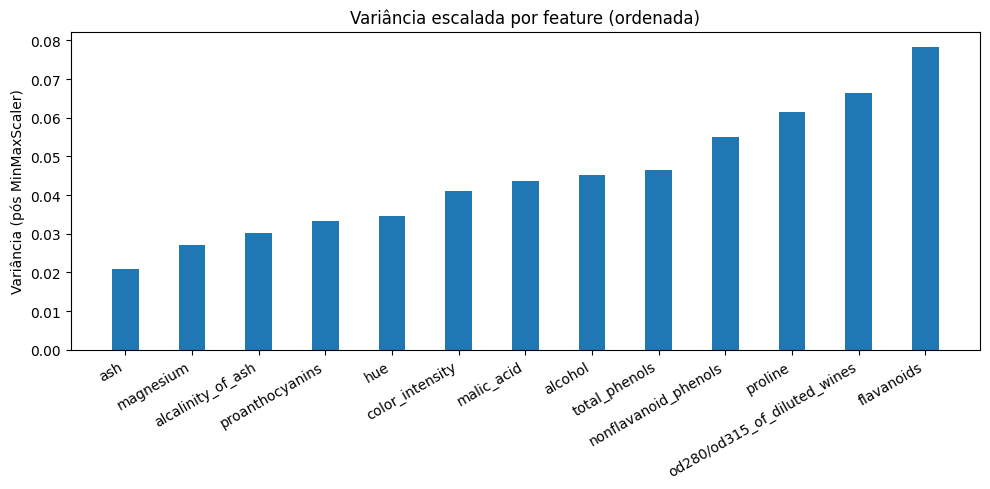

threshold=0.00000 -> 13 features mantidas: CV F1 = 0.899 +/- 0.047


threshold=0.02077 -> 12 features mantidas: CV F1 = 0.899 +/- 0.047


threshold=0.02720 -> 11 features mantidas: CV F1 = 0.891 +/- 0.046


threshold=0.03023 -> 10 features mantidas: CV F1 = 0.875 +/- 0.031


threshold=0.03329 -> 9 features mantidas: CV F1 = 0.866 +/- 0.023


threshold=0.03468 -> 8 features mantidas: CV F1 = 0.866 +/- 0.023

Melhor opção via CV: threshold=0.00000 (13 features, CV F1 = 0.899)


In [5]:
# MinMaxScaler leva cada feature para o intervalo [0, 1]: (x - min) / (max - min).
# Aplicado aqui só para o DIAGNÓSTICO visual abaixo (ver quais features têm menor variância);
# o scaler "de verdade", usado na avaliação, mora dentro do Pipeline mais abaixo, e é refeito
# a cada fold do CV -- este aqui é só para o gráfico exploratório.
scaler = MinMaxScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_var = pd.Series(scaled_X_train.var(axis=0), index=X_train.columns).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(scaled_var.index, scaled_var.values, width=0.4)
ax.set_ylabel("Variância (pós MinMaxScaler)")
ax.set_title("Variância escalada por feature (ordenada)")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# candidatos de threshold: logo acima de cada um dos 6 menores valores de variancia escalada
# -> cada candidato remove exatamente 0, 1, 2, ..., 5 features de menor variancia.
# Usamos o transformer VarianceThreshold de verdade, dentro de um Pipeline com o MinMaxScaler,
# para que o scaler seja reajustado a cada fold do CV (evita vazar estatistica de escala do
# fold de validacao para o de treino) -- diferente do original, que nem usava o transformer,
# só decidia "no olho" quais colunas descartar.
sorted_scaled_vars = scaled_var.values
candidate_thresholds = [0.0] + [sorted_scaled_vars[i] + 1e-6 for i in range(5)]

variance_results = []
for t in candidate_thresholds:
    # Pipeline: encadeia 3 passos que rodam em sequência sobre CADA fold do CV --
    #   1) MinMaxScaler   -> reescala as features para [0, 1] usando só o fold de treino
    #   2) VarianceThreshold(threshold=t) -> descarta colunas com variância < t
    #   3) make_gbc()     -> treina o classificador só com as colunas que sobraram
    pipe = Pipeline([
        ("scaler", MinMaxScaler()),
        ("vt", VarianceThreshold(threshold=t)),
        ("clf", make_gbc()),
    ])
    # cross_val_score treina+avalia este pipeline em cada um dos 5 folds de cv5 e devolve
    # um F1 por fold -- é a partir desse array que tiramos mean/std logo abaixo.
    scores = cross_val_score(pipe, X_train, y_train, cv=cv5, scoring="f1_weighted")

    # fit "solto" (fora do CV) só para reportar QUAIS colunas esse threshold manteria
    # se aplicado ao treino inteiro -- não influencia o número de F1 acima, é só para exibição.
    vt_full = VarianceThreshold(threshold=t).fit(scaled_X_train)
    n_kept = int(vt_full.get_support().sum())  # get_support(): array booleano, True = coluna mantida
    variance_results.append({"threshold": t, "n_features": n_kept, "cv_f1_mean": scores.mean(),
                              "cv_f1_std": scores.std(), "support_mask": vt_full.get_support()})
    print(f"threshold={t:.5f} -> {n_kept} features mantidas: CV F1 = {scores.mean():.3f} +/- {scores.std():.3f}")

best_variance_result = max(variance_results, key=lambda r: r["cv_f1_mean"])
bt, bn, bm = best_variance_result["threshold"], best_variance_result["n_features"], best_variance_result["cv_f1_mean"]
print(f"\nMelhor opção via CV: threshold={bt:.5f} ({bn} features, CV F1 = {bm:.3f})")


**Achado importante**: diferente do notebook original (que reportava uma MELHORA ao remover
`ash`/`magnesium`), a validação cruzada mostra que remover features de baixa variância aqui
**piora** ou, no melhor caso, empata o desempenho -- a melhora reportada no original foi um
acaso do split de teste, não um efeito real do `VarianceThreshold`.

In [6]:
variance_features = list(X_train.columns[best_variance_result["support_mask"]])
sel_X_train_vt = X_train[variance_features]
sel_X_test_vt = X_test[variance_features]

gbc_vt = make_gbc()
gbc_vt.fit(sel_X_train_vt, y_train)
f1_var_singlesplit = round(f1_score(y_test, gbc_vt.predict(sel_X_test_vt), average="weighted"), 3)
print("Features mantidas (VarianceThreshold, threshold escolhido por CV):", variance_features)
print("F1 (único split de teste, config escolhida por CV):", f1_var_singlesplit)


Features mantidas (VarianceThreshold, threshold escolhido por CV): ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
F1 (único split de teste, config escolhida por CV): 0.908


## 5. K-best (informação mútua) — `random_state` fixo, k escolhido por CV no treino

**O método, conceitualmente**: `SelectKBest` é um "filtro" — calcula, para cada feature
individualmente, um score de quão relacionada ela é ao alvo `y`, ordena as features por esse
score e mantém só as `k` melhores. O score usado aqui é **informação mútua** (`mutual_info_classif`):
diferente da correlação de Pearson, que só enxerga relações lineares, informação mútua mede
qualquer tipo de dependência estatística entre a feature e a classe (inclusive relações não
lineares) — quanto maior, mais "informação" sobre a classe a feature carrega. Por depender de um
estimador de vizinhos-mais-próximos internamente, `mutual_info_classif` tem uma peça de
aleatoriedade: sem fixar `random_state`, a mesma célula pode dar rankings ligeiramente
diferentes em cada execução (foi exatamente isso que reproduzimos no relatório, item 3).

Duas mudanças em relação ao original: (1) `mutual_info_classif` recebe `random_state` fixo via
`functools.partial` -- sem isso a varredura inteira não é reprodutível; (2) o k é escolhido pelo
desempenho médio em CV dentro do treino, nunca olhando o F1 de teste (esse é o item 1 do
relatório -- vazamento de dado).

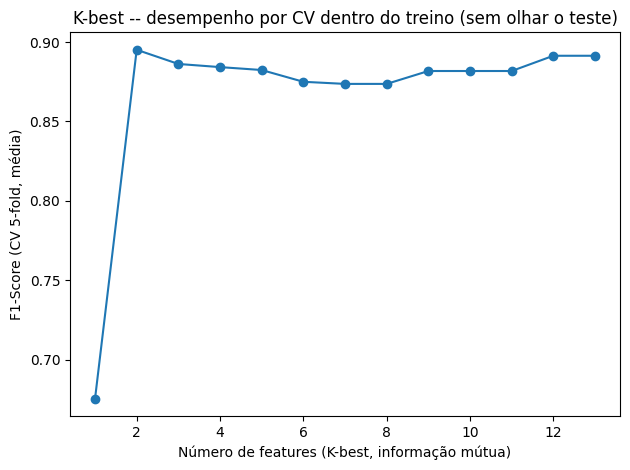

k escolhido via CV: 2 (CV F1 = 0.895)


In [7]:
# partial "trava" o argumento random_state dentro de mutual_info_classif, criando uma nova
# função que se comporta exatamente como a original mas sempre chamada com random_state=42.
# É necessário porque SelectKBest chama score_func(X, y) sem deixar passar kwargs extras --
# sem esse "partial", não haveria como fixar a semente e o resultado não seria reprodutível.
mi_seeded = partial(mutual_info_classif, random_state=RANDOM_STATE)

cv_means_kbest = []
for k in range(1, 14):
    # SelectKBest(mi_seeded, k=k): calcula a informação mútua de cada uma das 13 features
    # com y, e mantém só as k de maior score -- um "filtro" aplicado ANTES do classificador.
    pipe = Pipeline([("sel", SelectKBest(mi_seeded, k=k)), ("clf", make_gbc())])
    # de novo: cross_val_score refaz a seleção de features E o treino em cada fold,
    # então o "k melhores" pode variar ligeiramente de fold para fold -- isso é intencional
    # e correto (o contrário seria vazar informação do fold de validação).
    scores = cross_val_score(pipe, X_train, y_train, cv=cv5, scoring="f1_weighted")
    cv_means_kbest.append(scores.mean())

fig, ax = plt.subplots()
ax.plot(range(1, 14), cv_means_kbest, marker="o")
ax.set_xlabel("Número de features (K-best, informação mútua)")
ax.set_ylabel("F1-Score (CV 5-fold, média)")
ax.set_title("K-best -- desempenho por CV dentro do treino (sem olhar o teste)")
plt.tight_layout()
plt.show()

best_k_kbest = int(np.argmax(cv_means_kbest)) + 1
print(f"k escolhido via CV: {best_k_kbest} (CV F1 = {cv_means_kbest[best_k_kbest-1]:.3f})")


In [8]:
kbest_selector = SelectKBest(mi_seeded, k=best_k_kbest)
kbest_selector.fit(X_train, y_train)
kbest_features = list(X_train.columns[kbest_selector.get_support()])

sel_X_train_kb = kbest_selector.transform(X_train)
sel_X_test_kb = kbest_selector.transform(X_test)

gbc_kb = make_gbc()
gbc_kb.fit(sel_X_train_kb, y_train)
f1_kbest_singlesplit = round(f1_score(y_test, gbc_kb.predict(sel_X_test_kb), average="weighted"), 3)

print("Features selecionadas (K-best):", kbest_features)
print("F1 (único split de teste, k escolhido por CV, SEM vazamento):", f1_kbest_singlesplit)
print("(no notebook original, k=3 escolhido OLHANDO o teste dava F1 = 0.981 -- vazamento de dado)")


Features selecionadas (K-best): ['flavanoids', 'color_intensity']
F1 (único split de teste, k escolhido por CV, SEM vazamento): 0.926
(no notebook original, k=3 escolhido OLHANDO o teste dava F1 = 0.981 -- vazamento de dado)


## 6. RFE — `RFECV`, `step` consistente, sem olhar o teste

**O método, conceitualmente**: diferente de `SelectKBest` (que avalia cada feature
isoladamente), RFE ("Recursive Feature Elimination") avalia features **no contexto do modelo**:
treina o classificador com todas as features, olha a importância que o modelo deu a cada uma
(`feature_importances_`, no caso de árvores/boosting), descarta a(s) menos importante(s)
segundo o `step` (aqui, 1 por vez), e repete o processo — treina de novo com uma feature a
menos, descarta a próxima menos importante, e assim sucessivamente, até sobrar o número de
features pedido. É "recursivo" porque a importância é recalculada do zero a cada rodada (a
segunda feature menos importante pode mudar depois que a primeira é removida, já que o modelo
se reajusta ao conjunto reduzido).

O original varria k=1..13 medindo F1 de TESTE a cada k e escolhia k=3 visualmente (F1 = 1,000
nesse ponto) — isso são 13 execuções manuais do processo de eliminação inteiro, cada uma olhando
o teste para decidir se aquele k "valeu a pena". Aqui usamos **`RFECV`**, que é a mesma ideia de
eliminação recursiva, mas com a escolha de quantas features manter feita internamente por
validação cruzada **dentro do treino** — a ferramenta certa do sklearn para este problema
exato, elimina de uma vez tanto o vazamento de dado (item 1 do relatório) quanto a
inconsistência de `step` entre células (item 6).

RFECV concluído em 7.8s

Número de features escolhido via CV: 8
Features selecionadas (RFE): ['malic_acid', 'ash', 'magnesium', 'flavanoids', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


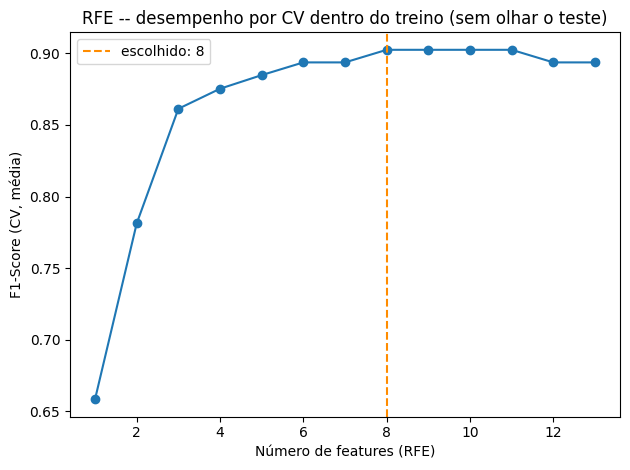

In [9]:
t0 = time.time()
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
# RFECV = RFE + validação cruzada embutida. Em cada fold de cv3, ele roda a eliminação
# recursiva completa (começa com as 13 features, remove 1 por vez -- step=1 -- até sobrar
# min_features_to_select) e mede o F1 em cada tamanho de subconjunto; no final, faz a média
# entre folds para cada tamanho e escolhe o tamanho com melhor média -- sem nunca tocar no
# conjunto de teste. n_jobs=-1 paraleliza usando todos os núcleos de CPU disponíveis.
rfecv = RFECV(estimator=make_gbc(), step=1, cv=cv3, scoring="f1_weighted",
              min_features_to_select=1, n_jobs=-1)
rfecv.fit(X_train, y_train)
print(f"RFECV concluído em {time.time()-t0:.1f}s")

# rfecv.support_: array booleano (True = feature mantida na config final escolhida)
rfe_features = list(X_train.columns[rfecv.support_])
print(f"\nNúmero de features escolhido via CV: {rfecv.n_features_}")
print("Features selecionadas (RFE):", rfe_features)

# rfecv.cv_results_["mean_test_score"] guarda o F1 médio de CV para CADA tamanho de
# subconjunto testado (de min_features_to_select até 13) -- é o equivalente, feito certo,
# do gráfico de varredura do notebook original (que usava F1 de TESTE em vez de CV).
fig, ax = plt.subplots()
n_feats_tested = len(rfecv.cv_results_["mean_test_score"])
ax.plot(range(1, n_feats_tested + 1), rfecv.cv_results_["mean_test_score"], marker="o")
ax.axvline(rfecv.n_features_, color="darkorange", linestyle="--", label=f"escolhido: {rfecv.n_features_}")
ax.set_xlabel("Número de features (RFE)")
ax.set_ylabel("F1-Score (CV, média)")
ax.set_title("RFE -- desempenho por CV dentro do treino (sem olhar o teste)")
ax.legend()
plt.tight_layout()
plt.show()


In [10]:
sel_X_train_rfe = rfecv.transform(X_train)
sel_X_test_rfe = rfecv.transform(X_test)

gbc_rfe = make_gbc()
gbc_rfe.fit(sel_X_train_rfe, y_train)
f1_rfe_singlesplit = round(f1_score(y_test, gbc_rfe.predict(sel_X_test_rfe), average="weighted"), 3)

print("F1 (único split de teste, k escolhido por CV, SEM vazamento):", f1_rfe_singlesplit)
print("(no notebook original, k=3 escolhido OLHANDO o teste dava F1 = 1.000 -- vazamento de dado)")

cm = confusion_matrix(y_test, gbc_rfe.predict(sel_X_test_rfe))
print("\nMatriz de confusão (RFE, config sem vazamento):")
print(cm)


F1 (único split de teste, k escolhido por CV, SEM vazamento): 0.908
(no notebook original, k=3 escolhido OLHANDO o teste dava F1 = 1.000 -- vazamento de dado)

Matriz de confusão (RFE, config sem vazamento):
[[16  2  0]
 [ 1 20  0]
 [ 1  1 13]]


A matriz de confusão acima tem uma linha e uma coluna por classe (0, 1, 2 -- as três
castas de uva do dataset `wine`). A linha `i`, coluna `j` conta quantas amostras que
PERTENCEM à classe `i` foram PREVISTAS como classe `j`. A diagonal principal (posições [0,0],
[1,1], [2,2]) são os acertos; qualquer valor fora da diagonal é um erro de classificação. Vale
conferir esta matriz sempre que um F1 chamar muita atenção (bom ou ruim demais) -- é o jeito
mais direto de ver ONDE o modelo está errando, não só quanto.

## 7. Boruta

**O método, conceitualmente**: Boruta ataca o problema de um jeito diferente de tudo que veio
antes. Para cada feature real, ele cria uma cópia embaralhada dela (uma "shadow feature" —
os mesmos valores, mas numa ordem aleatória, o que destrói qualquer relação real com `y`).
Treina o modelo com as features reais + todas as shadows juntas, e compara a importância de
cada feature real contra a MAIOR importância obtida entre todas as shadows: se uma feature real
não consegue nem superar a melhor feature de ruído puro, ela é descartada. Isso se repete por
várias iterações (votação), e o processo é estatisticamente mais rigoroso que "top-k por
importância" (K-best e RFE): em vez de perguntar "quais são as k melhores?", o Boruta pergunta
"quais features carregam sinal genuíno, mesmo que fraco?" — por isso costuma manter mais
features do que K-best/RFE (aqui, 9 em vez de 2 ou 8). Essa é a diferença entre os dois grandes
grupos de método de seleção de features: **minimal-optimal** (K-best, RFE — buscam o MENOR
subconjunto que ainda maximiza a métrica) e **all-relevant** (Boruta — busca TODAS as features
com sinal real, mesmo redundantes entre si).

Testado de fato neste ambiente antes de qualquer afirmação sobre ele (numpy/scikit-learn
atuais) -- funciona sem erro. Diferente de K-best/RFE, o algoritmo já é construído em torno da
comparação com features de ruído, então não há um "k" externo escolhido à mão para vazar via
teste -- mas ainda assim avaliamos o subconjunto resultante por CV, não só um split.

In [11]:
try:
    from boruta import BorutaPy
    boruta_ok = True
except ImportError:
    boruta_ok = False
    print("[aviso] pacote 'boruta' não instalado (pip install boruta) -- pulando esta seção.")

if boruta_ok:
    # BorutaPy recebe um estimador baseado em árvore (precisa expor feature_importances_) e
    # roda o processo de shadow features descrito acima; .values converte de DataFrame pandas
    # para array numpy puro, que é o formato que esta biblioteca espera.
    boruta_selector = BorutaPy(make_gbc(), random_state=RANDOM_STATE)
    boruta_selector.fit(X_train.values, y_train.values.ravel())

    # .support_: True para cada feature que sobreviveu à votação contra as shadow features
    boruta_features = list(X_train.columns[boruta_selector.support_])
    print("Features selecionadas (Boruta):", boruta_features)

    sel_X_train_bo = X_train[boruta_features]
    sel_X_test_bo = X_test[boruta_features]

    gbc_bo = make_gbc()
    gbc_bo.fit(sel_X_train_bo, y_train)
    f1_boruta_singlesplit = round(f1_score(y_test, gbc_bo.predict(sel_X_test_bo), average="weighted"), 3)
    print("F1 (único split de teste):", f1_boruta_singlesplit)
else:
    boruta_features = list(X_train.columns)  # fallback -- equivalente a "todas as features"
    f1_boruta_singlesplit = f1_all_singlesplit


Features selecionadas (Boruta): ['malic_acid', 'ash', 'magnesium', 'flavanoids', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


F1 (único split de teste): 0.908


## 8. Comparação final honesta: validação cruzada REPETIDA, não um único split

Em vez do gráfico de barras do original (um valor por técnica, alguns hardcoded), comparamos a
DISTRIBUIÇÃO de F1 de cada configuração via `RepeatedStratifiedKFold` (5 folds × 3 repetições =
**15 medições por técnica**, em vez de 1) -- isso é o que permite dizer se uma diferença é real
ou só ruído: se as distribuições de duas técnicas se sobrepõem bastante, a diferença entre suas
médias não é confiável; se ficam claramente separadas, é.

In [12]:
configs = {
    "Todas as features": list(X_train.columns),
    "Variance threshold (CV)": variance_features,
    "K-best MI (CV)": kbest_features,
    "RFE (RFECV)": rfe_features,
}
if boruta_ok:
    configs["Boruta"] = boruta_features

# RepeatedStratifiedKFold(n_splits=5, n_repeats=3): faz 3 rodadas independentes de um
# StratifiedKFold de 5 folds cada, reembaralhando os dados a cada rodada -- resultando em
# 5*3=15 medições de F1 por configuração, em vez das 5 de um StratifiedKFold comum.
rcv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)
cv_distributions = {}
for name, cols in configs.items():
    # X_train[cols]: reindexa o DataFrame só com as colunas que aquele método selecionou
    scores = cross_val_score(make_gbc(), X_train[cols], y_train, cv=rcv, scoring="f1_weighted", n_jobs=-1)
    cv_distributions[name] = scores  # array de 15 valores de F1

summary_rows = []
for name, scores in cv_distributions.items():
    summary_rows.append({
        "método": name,
        "n_features": len(configs[name]),
        "cv_f1_mean": round(scores.mean(), 3),
        "cv_f1_std": round(scores.std(), 3),
    })
summary_df = pd.DataFrame(summary_rows).sort_values("cv_f1_mean", ascending=False).reset_index(drop=True)
summary_df


,método,n_features,cv_f1_mean,cv_f1_std
0,Todas as features,13,0.901,0.044
1,Variance threshold (CV),13,0.901,0.044
2,K-best MI (CV),2,0.895,0.054
3,RFE (RFECV),8,0.892,0.045
4,Boruta,9,0.892,0.045


O boxplot abaixo resume a distribuição de 15 medições de F1 por método: a caixa cobre do
25º ao 75º percentil (onde ficam os "valores típicos"), a linha no meio é a mediana, e os
"bigodes" mostram a faixa de valores fora disso. Caixas que se sobrepõem bastante entre si
indicam que a diferença de desempenho entre esses métodos não é conclusiva -- é só o que os
gráficos de barra de um único ponto (como o do notebook original) escondem.

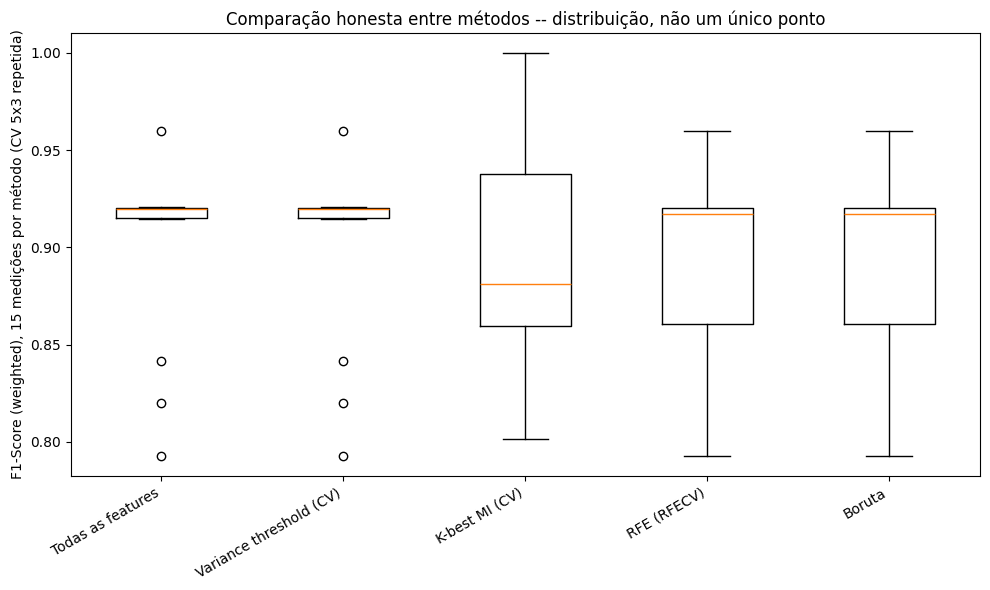

Note que as caixas se sobrepõem fortemente -- nenhuma técnica bate a baseline de forma
estatisticamente convincente. O ganho real de K-best/RFE aqui é SIMPLICIDADE
(2 a 9 features em vez de 13 com desempenho equivalente), não acurácia.


In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
labels = list(cv_distributions.keys())
data = [cv_distributions[l] for l in labels]
ax.boxplot(data, tick_labels=labels)
ax.set_ylabel("F1-Score (weighted), 15 medições por método (CV 5x3 repetida)")
ax.set_title("Comparação honesta entre métodos -- distribuição, não um único ponto")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print("Note que as caixas se sobrepõem fortemente -- nenhuma técnica bate a baseline de forma")
print("estatisticamente convincente. O ganho real de K-best/RFE aqui é SIMPLICIDADE")
print("(2 a 9 features em vez de 13 com desempenho equivalente), não acurácia.")


## 9. Overlap de features entre métodos e recomendação final

Cada técnica usa um critério diferente para escolher features (variância isolada, informação
mútua isolada, importância recursiva no modelo, votação contra ruído) -- por isso é informativo
ver quais features aparecem selecionadas por VÁRIOS métodos ao mesmo tempo: é um sinal mais
forte de que aquela feature carrega sinal real do que ela ter sido escolhida por um único
método.

In [14]:
all_selected = {
    "Variance threshold": set(variance_features),
    "K-best MI": set(kbest_features),
    "RFE": set(rfe_features),
}
if boruta_ok:
    all_selected["Boruta"] = set(boruta_features)

overlap_rows = []
for feat in X_train.columns:
    row = {"feature": feat}
    for method, feats in all_selected.items():
        row[method] = feat in feats
    row["n_metodos"] = sum(row[m] for m in all_selected)
    overlap_rows.append(row)

overlap_df = pd.DataFrame(overlap_rows).sort_values("n_metodos", ascending=False).reset_index(drop=True)
overlap_df


,feature,Variance threshold,K-best MI,RFE,Boruta,n_metodos
0,flavanoids,True,True,True,True,4
1,color_intensity,True,True,True,True,4
2,ash,True,False,True,True,3
3,magnesium,True,False,True,True,3
4,malic_acid,True,False,True,True,3
5,proline,True,False,True,True,3
6,od280/od315_of_diluted_wines,True,False,True,True,3
7,hue,True,False,True,True,3
8,proanthocyanins,True,False,False,True,2
9,alcalinity_of_ash,True,False,False,False,1


In [15]:
core_features = overlap_df[overlap_df["n_metodos"] == overlap_df["n_metodos"].max()]["feature"].tolist()
best_method = summary_df.iloc[0]["método"]
best_mean = summary_df.iloc[0]["cv_f1_mean"]
smallest_equivalent = summary_df.loc[summary_df["cv_f1_mean"] >= summary_df["cv_f1_mean"].max() - 0.02] \
    .sort_values("n_features").iloc[0]

print(f"Features presentes em mais métodos ao mesmo tempo: {core_features}")
print(f"\nMelhor CV F1 médio: {best_method} ({best_mean:.3f})")
print(f"Configuração mais enxuta com desempenho equivalente (dentro de 0.02 do melhor): "
      f"{smallest_equivalent['método']} com {int(smallest_equivalent['n_features'])} features "
      f"(CV F1 = {smallest_equivalent['cv_f1_mean']:.3f})")
print("\nRecomendação: como nenhum método bate a baseline de forma estatisticamente robusta,")
print("a escolha deve ser guiada por SIMPLICIDADE/custo de manutenção -- levar adiante a")
print(f"configuração mais enxuta com desempenho equivalente ('{smallest_equivalent['método']}'),")
print("não a que tem o maior número decorado de casas decimais num único split de teste.")


Features presentes em mais métodos ao mesmo tempo: ['flavanoids', 'color_intensity']

Melhor CV F1 médio: Todas as features (0.901)
Configuração mais enxuta com desempenho equivalente (dentro de 0.02 do melhor): K-best MI (CV) com 2 features (CV F1 = 0.895)

Recomendação: como nenhum método bate a baseline de forma estatisticamente robusta,
a escolha deve ser guiada por SIMPLICIDADE/custo de manutenção -- levar adiante a
configuração mais enxuta com desempenho equivalente ('K-best MI (CV)'),
não a que tem o maior número decorado de casas decimais num único split de teste.


## 10. Persistência

Salvamos o modelo final (treinado na configuração recomendada, no treino inteiro) e a lista de
features usada -- nada disso existia no notebook original.

In [16]:
final_features = configs[smallest_equivalent["método"]]
final_model = make_gbc()
final_model.fit(X_train[final_features], y_train)
final_f1_test = round(f1_score(y_test, final_model.predict(X_test[final_features]), average="weighted"), 3)

joblib.dump(
    {"model": final_model, "features": list(final_features), "method": smallest_equivalent["método"]},
    "modelo_feature_selection_final.joblib",
)
print(f"Modelo final: {smallest_equivalent['método']} ({len(final_features)} features)")
print("Features:", list(final_features))
print(f"F1 no holdout (referência, não usado para escolher a config): {final_f1_test}")
print("Salvo em modelo_feature_selection_final.joblib")


Modelo final: K-best MI (CV) (2 features)
Features: ['flavanoids', 'color_intensity']
F1 no holdout (referência, não usado para escolher a config): 0.926
Salvo em modelo_feature_selection_final.joblib


## Conclusão

O achado mais importante deste notebook não é "qual técnica de seleção de features é melhor" --
é que, sob avaliação rigorosa, **nenhuma delas melhora a acurácia neste dataset** de forma
estatisticamente defensável; os ganhos aparentes no notebook original vieram de vazamento de
dado (escolher k olhando o teste) e da variância natural de um único split pequeno. O valor real
da seleção de features aqui é simplicidade — chegar em 2 a 9 features com desempenho equivalente
às 13 originais — não o número de F1 "recorde" que mais chama atenção num gráfico de barras.
Ver `RELATORIO_ANALISE_FEATURE_SELECTION.md` para o diagnóstico completo.
